In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Iterator)=
# Iterator

*Iterating over topological and structural attributes of a molecular system.*

MolSysMT provides a convenient tool to iterate over topological and structural attributes of a molecular system. This tool — the class {class}`molsysmt.basic.Iterator` — supports standard control arguments like `start`, `stop`, `step`, and `chunk`, regardless of the attribute type.

:class: dropdown

Visit the section {ref}`Introduction_Attributes` for a detailed overview of attributes in MolSysMT.


:class: dropdown



## Basic usage

Let's show how this class works with demonstration datasets (`chicken villin HP35` and `pentalanine`):


## Iterations over topological attributes

Suppose we want to iterate over topological attributes such as `atom_name` or `group_index`.
The class {class}`molsysmt.basic.Iterator` is designed for this purpose.


Have a look to the following code:

In [2]:
import molsysmt as msm

In [3]:
molsys = msm.systems['chicken villin HP35']['1vii.bcif.gz']

:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


In [4]:
iterator = msm.Iterator(molsys, selection='atom_name=="CA" and group_index<10',
                        atom_index=True, atom_name=True, group_index=True, group_name=True)

:::{tip}
:class: dropdown

All objects defined in the {ref}`molsysmt.basic <API basic>` module can also be invoked from the main level of the library. Hence, {class}`molsysmt.Iterator` is the same class as {class}`molsysmt.basic.Iterator`.
:::


In [5]:
for atom_index, atom_name, group_index, group_name in iterator:
    print(atom_index, atom_name, group_index, group_name)

[0] ['N'] [0] ['MET']
[1] ['CA'] [0] ['MET']
[2] ['C'] [0] ['MET']
[3] ['O'] [0] ['MET']
[4] ['CB'] [0] ['MET']
[5] ['CG'] [0] ['MET']
[6] ['SD'] [0] ['MET']
[7] ['CE'] [0] ['MET']
[8] ['H1'] [0] ['MET']
[9] ['H2'] [0] ['MET']


The class {class}`molsysmt.basic.Iterator` allows us to work with a loop running over a selection of atoms. The set of attributes we want to extract are introduced together with the rest of instantation arguments in a similar way they are indicated in {func}`molsysmt.basic.get`. But, is the iterator only running over atoms? Not at all. The `element` argument can be set to other leves such as `group`, `component`, `chain`, `molecule` or `entity`. Check this next case:

In [6]:
iterator = msm.Iterator(molsys, element='group', selection='molecule_type=="peptide"',
                        group_index=True, group_name=True)

In [7]:
for group_index, group_name in iterator:
    print(group_index, group_name)

[0] ['MET']
[1] ['LEU']
[2] ['SER']
[3] ['ASP']
[4] ['GLU']
[5] ['ASP']
[6] ['PHE']
[7] ['LYS']
[8] ['ALA']
[9] ['VAL']
[10] ['PHE']
[11] ['GLY']
[12] ['MET']
[13] ['THR']
[14] ['ARG']
[15] ['SER']
[16] ['ALA']
[17] ['PHE']
[18] ['ALA']
[19] ['ASN']
[20] ['LEU']
[21] ['PRO']
[22] ['LEU']
[23] ['TRP']
[24] ['LYS']
[25] ['GLN']
[26] ['GLN']
[27] ['ASN']
[28] ['LEU']
[29] ['LYS']
[30] ['LYS']
[31] ['GLU']
[32] ['LYS']
[33] ['GLY']
[34] ['LEU']
[35] ['PHE']


For more advanced iteration control, you can use the arguments `start`, `stop`, `step` and `chunk`.

In [8]:
iterator = msm.Iterator(molsys, element='atom', start=10, stop=40, step=2, chunk=5,
                        atom_index=True, atom_name=True)

In [9]:
for atom_indices, atom_names in iterator:
    print(atom_indices, atom_names)

[10, 12, 14, 16, 18] ['H3', 'HB2', 'HG2', 'HE1', 'HE3']
[20, 22, 24, 26, 28] ['CA', 'O', 'CG', 'CD2', 'HA']
[30, 32, 34, 36, 38] ['HB3', 'HD11', 'HD13', 'HD22', 'N']


:::{tip}
:class: dropdown

If you want to extract values of topological or structural attributes directly, {class}`molsysmt.basic.Iterator` is not the only way. You can also use {func}`molsysmt.basic.get` (see {ref}`Tutorial_Get`).
:::


## Iterations over structural attributes

In this section, let's suppose we have a molecular system with different structures: a molecular dynamics trajectory file, for instance.
And let's see how the class {class}`molsysmt.basic.Iterator` can be used to iterate over structural attributes such as `coordinates`, `box` or `time`. 


Here we have an example:

In [10]:
molsys = msm.systems['pentalanine']['traj_pentalanine.h5']

In [11]:
iterator = msm.Iterator(molsys, time=True, temperature=True)


All methods defined in the {ref}`molsysmt.basic <API basic>` module can be invoked also from the main level of the library. Hence, {func}`molsysmt.Iterator` is the same method as {func}`molsysmt.basic.Iterator`.


In [12]:
times = []
temperatures = []

for time, temperature in iterator:
    times.append(time)
    temperatures.append(temperature)

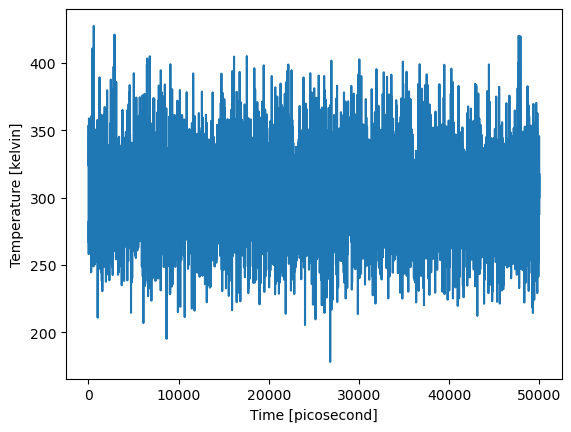

In [13]:
import matplotlib.pyplot as plt
import pyunitwizard as puw
import numpy as np

times = puw.utils.sequences.concatenate(times)
temperatures = puw.utils.sequences.concatenate(temperatures)

plt.plot(times, temperatures)
plt.xlabel(f'Time [{puw.get_unit(times)}]')
plt.ylabel(f'Temperature [{puw.get_unit(temperatures)}]')
plt.show()

The iterator includes some useful input arguments such as `selection` or `structure_indices`:

In [14]:
iterator = msm.Iterator(molsys, selection='group_index==3 and atom_name=="CA"',
                        structure_indices=[100, 110, 120], time=True, coordinates=True)

In [15]:
for time, coordinates in iterator:
    print(time, coordinates)

[1010.0] picosecond [[[0.9690295457839966 1.146891474723816 -0.1522401124238968]]] nanometer
[1110.0] picosecond [[[1.023858666419983 1.377505898475647 0.03329920768737793]]] nanometer
[1210.0] picosecond [[[0.9038813710212708 1.1570117473602295 0.03575613722205162]]] nanometer


And four iteration control arguments: `start`, `stop`, `step` and `chunk`.

In [16]:
iterator = msm.Iterator(molsys, start=500, stop=510, step=2, time=True)

In [17]:
for structure_id in iterator:
    print(structure_id)

[5010.0] picosecond
[5030.0] picosecond
[5050.0] picosecond
[5070.0] picosecond
[5090.0] picosecond


Let's see two other examples on how to use these arguments:

In [18]:
iterator = msm.Iterator(molsys, start=500, stop=520, step=2, chunk=5, time=True)

for times in iterator:
    print(times)

[5010.0 5030.0 5050.0 5070.0 5090.0] picosecond
[5110.0 5130.0 5150.0 5170.0 5190.0] picosecond


In [19]:
my_structure_indices = [1000, 1013, 1021, 1034, 1055, 1067, 1084, 1093, 1105]

iterator = msm.Iterator(molsys, structure_indices=my_structure_indices,
                        start=2, step=2, chunk=2, time=True)

for times in iterator:
    print(times)

[10220.0 10560.0] picosecond
[10850.0 11060.0] picosecond


Finally, if no specific attribute is requested, the iterator returns molecular system objects, one per iteration, with structural attributes updated accordingly.

In [20]:
iterator = msm.Iterator(molsys, start=1000, stop=1006, chunk=3)

In [21]:
for aux_molsys in iterator:
    time, box_volume = msm.get(aux_molsys, time=True, box_volume=True)
    print(time, box_volume)

[10010.0 10020.0 10030.0] picosecond [7.999999999999998 7.999999999999998 7.999999999999998] nanometer ** 3
[10040.0 10050.0 10060.0] picosecond [7.999999999999998 7.999999999999998 7.999999999999998] nanometer ** 3


In this former case the output form was required by default as 'molsysmt.MolSys', but it can be change with the input argument `output_form`.

:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Introduction_Attributes`: Describe the available topological and structural attributes in MolSysMT.
- {ref}`user-foundations-entrance-demo-systems`: Explore demonstration datasets used for testing and tutorials.
- {ref}`Tutorial_Iterator`: Iterate over topological and structural attributes of a molecular system with {class}`molsysmt.basic.Iterator`.
- {ref}`Tutorial_Get`: Retrieve attribute values directly from a molecular system with {func}`molsysmt.basic.get`.
- {ref}`Tutorial_Select`: Select specific elements of a molecular system using selection syntax with {func}`molsysmt.basic.select`.
:::
